In [26]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
# Seasonality
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [3]:
df = pd.read_csv('../time_series_analysis/intro_to_time_series/weekly_customer_complaints.csv', parse_dates=True, index_col='week')
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   complaints               261 non-null    object
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 12.2+ KB


Data- preprocessing

In [8]:
# Remove comma and transform to float
df['complaints']=df['complaints'].str.replace(',', '').astype(float)
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750.0,37.26%,1,0,0
2018-01-08,1701.0,35.38%,0,0,0
2018-01-15,1711.0,36.22%,1,0,0
2018-01-22,1443.0,38.33%,1,0,0
2018-01-29,1397.0,36.34%,0,0,0


In [9]:
# setting freq to W implies that the week starts on Sunday
df = df.asfreq('W-Mon')  
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq='W-MON')

Exploratory data analysis

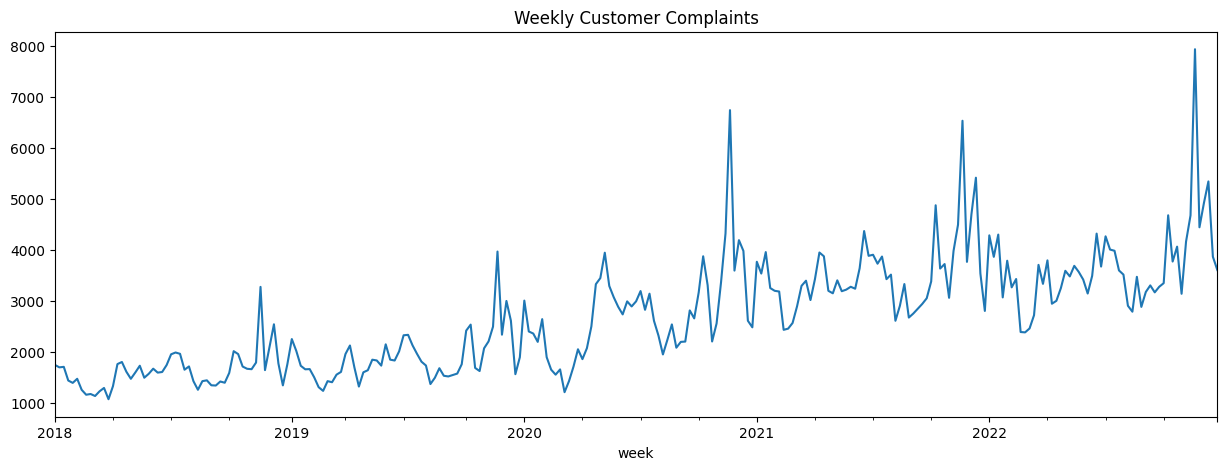

In [10]:
df['complaints'].plot(figsize=(15, 5))
plt.title('Weekly Customer Complaints')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_9400\2104844781.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df['complaints'].resample('M').mean(),


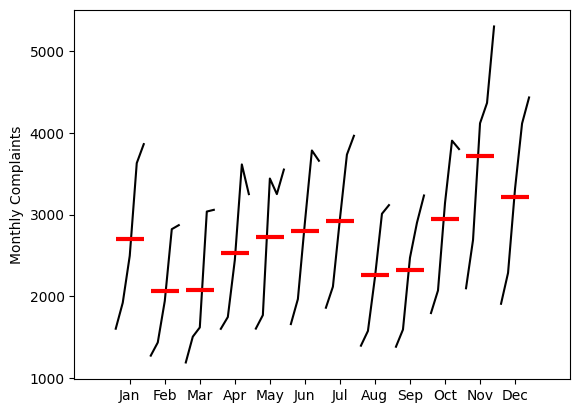

In [12]:
# Plotting the monthly seasonality
month_plot(df['complaints'].resample('M').mean(),
           ylabel='Monthly Complaints')
plt.show()   


C:\Users\msi\AppData\Local\Temp\ipykernel_9400\2996227978.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['complaints'].resample('Q').mean(),


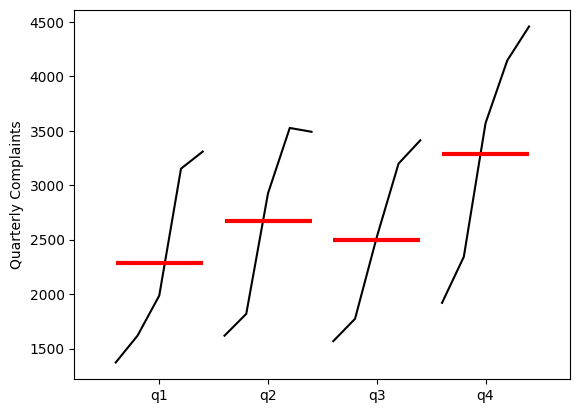

In [13]:
# Plotting the quarterly seasonality
quarter_plot(df['complaints'].resample('Q').mean(),
                ylabel='Quarterly Complaints')
plt.show()

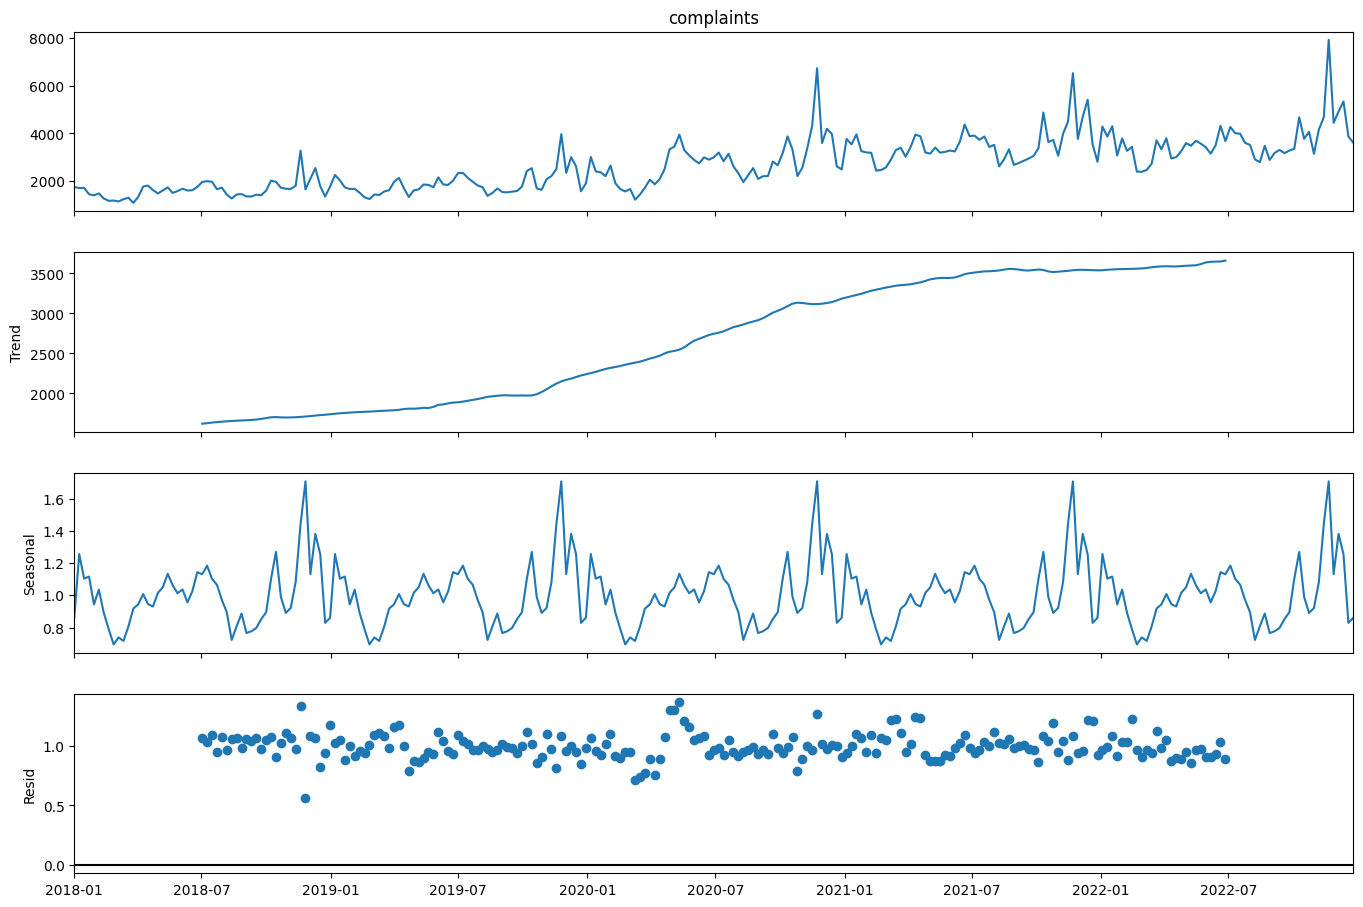

In [14]:
# Seasonal decomposition
decompostion = seasonal_decompose(df['complaints'], model='multiplicative', period=52)
fig = decompostion.plot()
fig.set_size_inches(15, 10) 
plt.show()

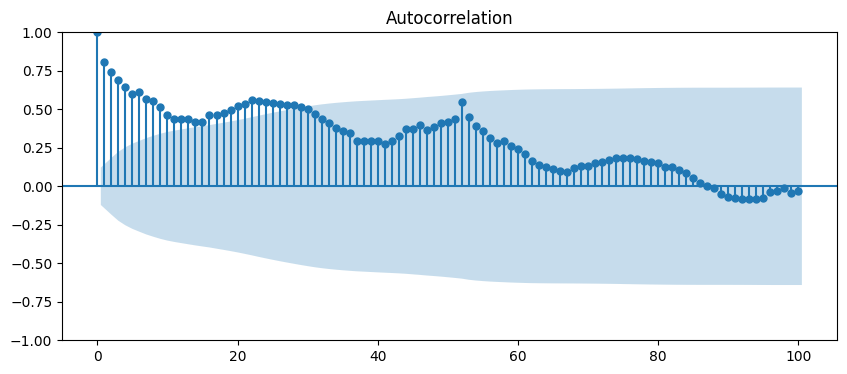

In [18]:
# Plot the autocorrelation 
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df['complaints'], lags=100, ax=ax)
plt.show()

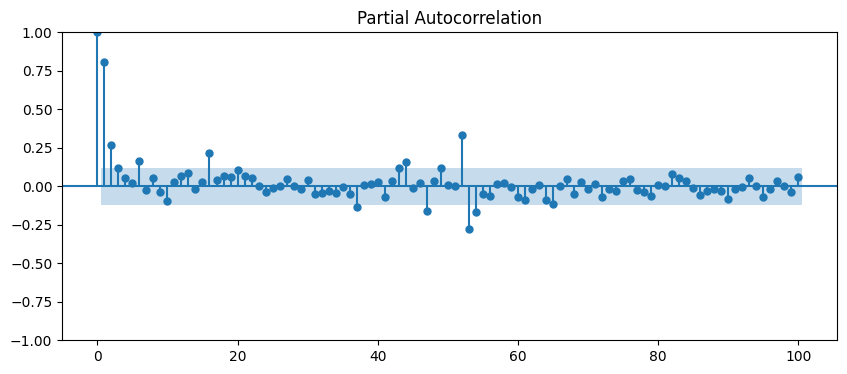

In [20]:
# Plot the partial autocorrelation

fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(df['complaints'], lags=100, ax=ax)
plt.show()

# Training and test

 Goal: to predict the nedxt quarter( 13 weeks)

In [25]:
# Training and test split
periods = 13
train, test = df.iloc[:-periods,0], df.iloc[-periods:, 0 ]
test.head()

week
2022-10-03    3350.0
2022-10-10    4679.0
2022-10-17    3773.0
2022-10-24    4065.0
2022-10-31    3142.0
Freq: W-MON, Name: complaints, dtype: float64

In [23]:
test

week
2022-10-03    3350.0
2022-10-10    4679.0
2022-10-17    3773.0
2022-10-24    4065.0
2022-10-31    3142.0
2022-11-07    4164.0
2022-11-14    4677.0
2022-11-21    7931.0
2022-11-28    4444.0
2022-12-05    4920.0
2022-12-12    5342.0
2022-12-19    3868.0
2022-12-26    3607.0
Freq: W-MON, Name: complaints, dtype: float64

Simple Exponential Smoothings

In [28]:
# Simple Exponential Smoothing model and Prediction
model_simple = ExponentialSmoothing(train).fit()
model_simple.forecast(len(test))

2022-10-03    3236.624683
2022-10-10    3236.624683
2022-10-17    3236.624683
2022-10-24    3236.624683
2022-10-31    3236.624683
2022-11-07    3236.624683
2022-11-14    3236.624683
2022-11-21    3236.624683
2022-11-28    3236.624683
2022-12-05    3236.624683
2022-12-12    3236.624683
2022-12-19    3236.624683
2022-12-26    3236.624683
Freq: W-MON, dtype: float64

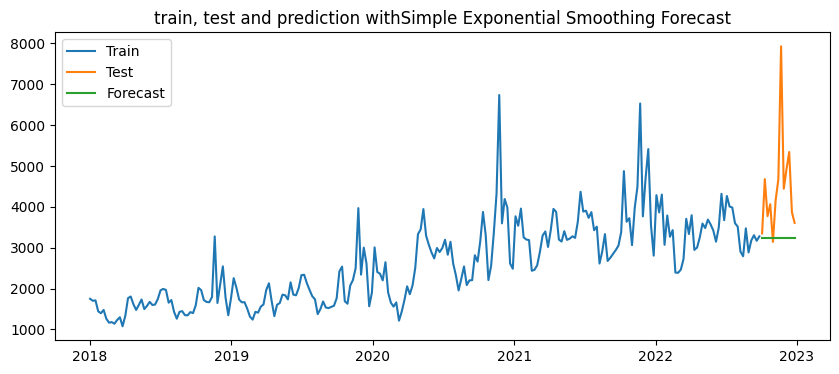

In [34]:
# Plot training, test and forecasts
plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(model_simple.forecast(len(test)), label='Forecast')
plt.title('train, test and prediction withSimple Exponential Smoothing Forecast')
plt.legend()
plt.show()